In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

# Computer Vision
import cv2
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Scikit-learn for evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
OpenCV version: 4.12.0
GPU Available: []


## Loading Data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sureshmaheshwari021/cats-and-dogs")

print("Path to dataset files:", path)

100%|██████████| 134M/134M [00:01<00:00, 132MB/s]


Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/sureshmaheshwari021/cats-and-dogs/versions/1


In [3]:
pip install pydot

## EDA

Dataset: 1
Number of classes: 2
Classes: ['cats', 'dogs']

cats: 95 images
dogs: 97 images

Total images: 192


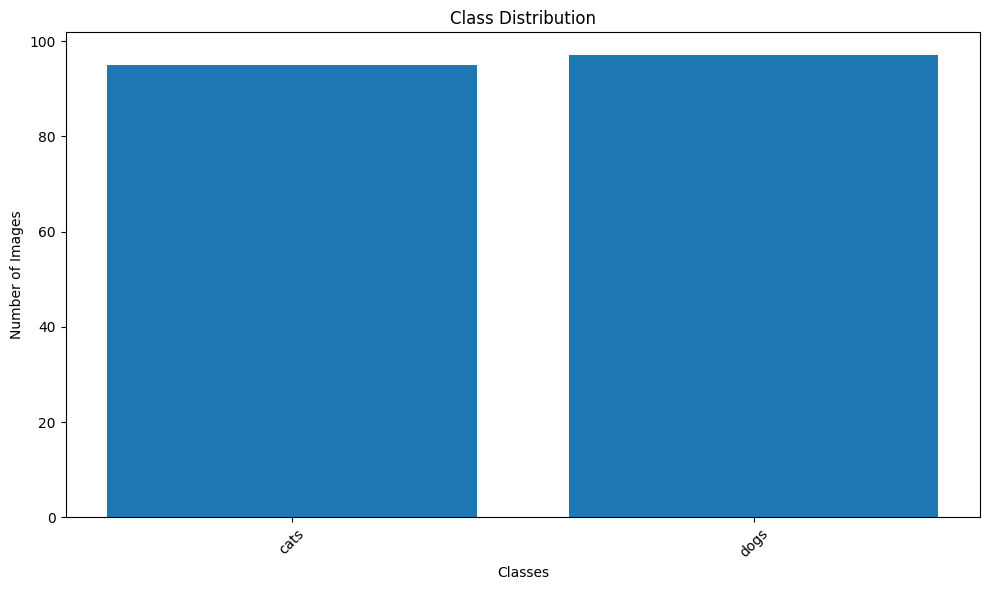

In [4]:
def explore_dataset_structure(dataset_path):
    """
    Explore the structure and statistics of the image dataset
    """
    dataset_path = Path(dataset_path)

    # Get class directories
    class_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    class_names = [d.name for d in class_dirs]

    print(f"Dataset: {dataset_path.name}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Classes: {class_names}")
    print("\n" + "="*50)

    # Count images per class
    class_counts = {}
    total_images = 0

    for class_dir in class_dirs:
        image_files = list(class_dir.glob('*.png')) + list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg'))
        count = len(image_files)
        class_counts[class_dir.name] = count
        total_images += count
        print(f"{class_dir.name}: {count} images")

    print(f"\nTotal images: {total_images}")

    # Visualize class distribution
    plt.figure(figsize=(10, 6))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.title('Class Distribution')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return class_names, class_counts

# Explore our dataset
class_names, class_counts = explore_dataset_structure(path)

Image Statistics Summary:
            widths     heights  channels   file_sizes
count    20.000000    20.00000      20.0    20.000000
mean   1916.150000  1210.45000       3.0   283.255713
std    1075.286952   757.80816       0.0   270.841072
min     480.000000   270.00000       3.0    26.748047
25%    1125.000000   619.50000       3.0    80.161133
50%    1600.000000  1033.50000       3.0   227.023438
75%    2515.000000  1683.00000       3.0   349.553955
max    4000.000000  2700.00000       3.0  1094.867188


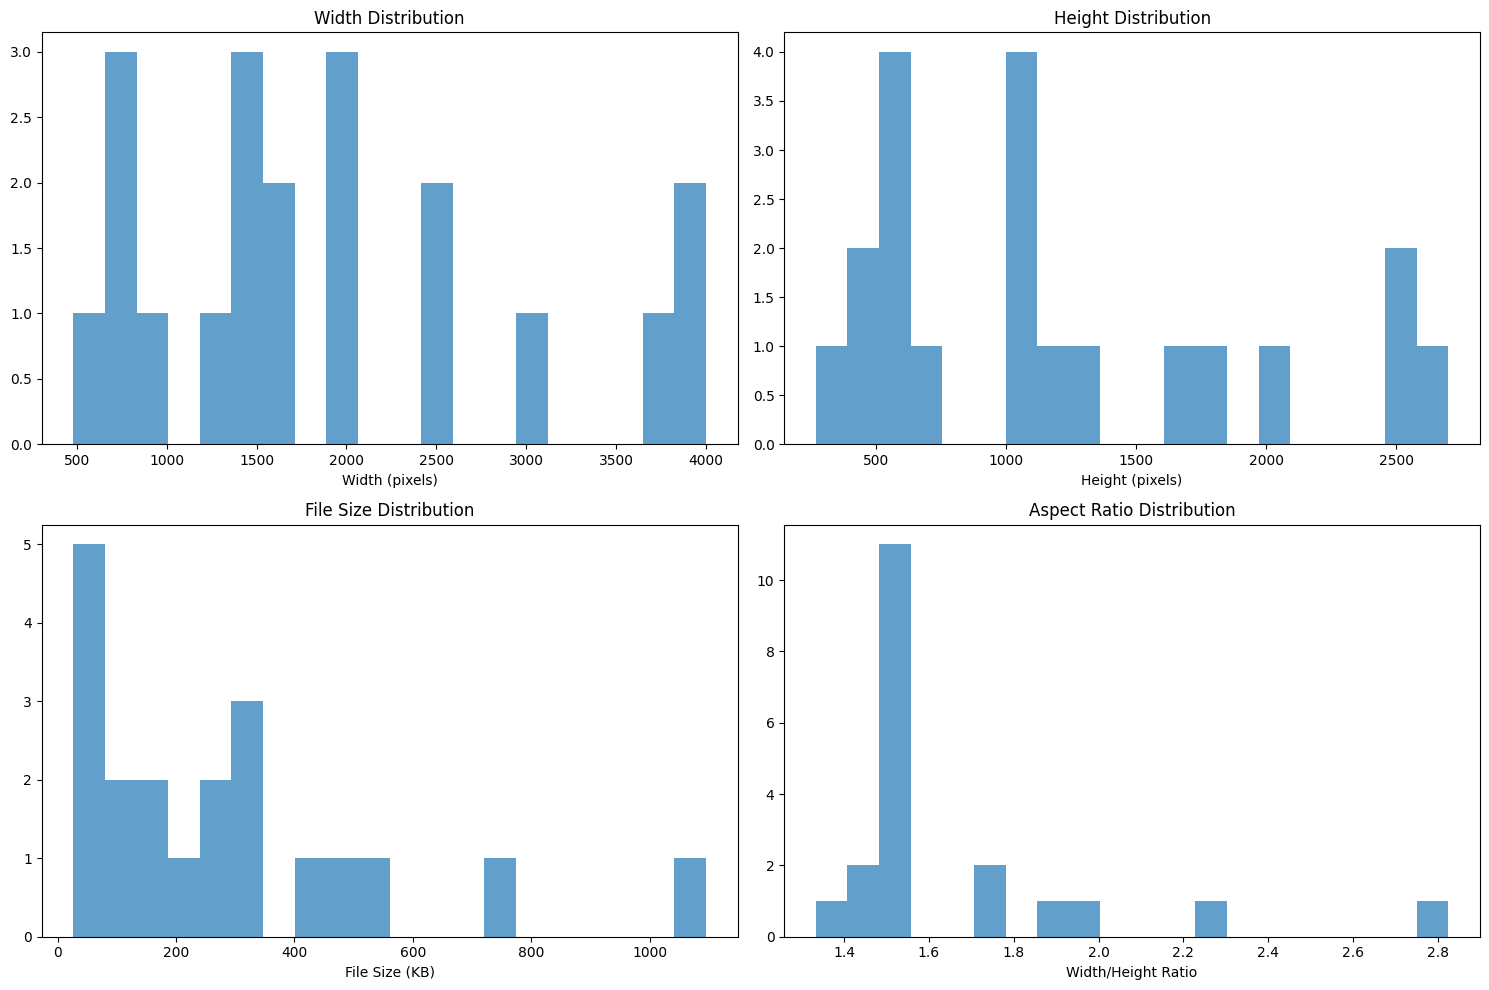

In [5]:
def analyze_image_properties(dataset_path, class_names, sample_size=10):
    """
    Analyze image properties like dimensions, channels, file sizes
    """
    dataset_path = Path(dataset_path)

    image_stats = {
        'widths': [],
        'heights': [],
        'channels': [],
        'file_sizes': [],
        'classes': []
    }

    # Sample images from each class
    for class_name in class_names:
        class_dir = dataset_path / class_name
        image_files = list(class_dir.glob('*.jpg'))[:sample_size]

        for img_path in image_files:
            # Load image
            img = cv2.imread(str(img_path))
            if img is not None:
                h, w, c = img.shape
                file_size = img_path.stat().st_size / 1024  # KB

                image_stats['heights'].append(h)
                image_stats['widths'].append(w)
                image_stats['channels'].append(c)
                image_stats['file_sizes'].append(file_size)
                image_stats['classes'].append(class_name)

    # Convert to DataFrame for analysis
    df_stats = pd.DataFrame(image_stats)

    print("Image Statistics Summary:")
    print(df_stats.describe())

    # Visualize distributions
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Width distribution
    axes[0, 0].hist(df_stats['widths'], bins=20, alpha=0.7)
    axes[0, 0].set_title('Width Distribution')
    axes[0, 0].set_xlabel('Width (pixels)')

    # Height distribution
    axes[0, 1].hist(df_stats['heights'], bins=20, alpha=0.7)
    axes[0, 1].set_title('Height Distribution')
    axes[0, 1].set_xlabel('Height (pixels)')

    # File size distribution
    axes[1, 0].hist(df_stats['file_sizes'], bins=20, alpha=0.7)
    axes[1, 0].set_title('File Size Distribution')
    axes[1, 0].set_xlabel('File Size (KB)')

    # Aspect ratio
    aspect_ratios = df_stats['widths'] / df_stats['heights']
    axes[1, 1].hist(aspect_ratios, bins=20, alpha=0.7)
    axes[1, 1].set_title('Aspect Ratio Distribution')
    axes[1, 1].set_xlabel('Width/Height Ratio')

    plt.tight_layout()
    plt.show()

    return df_stats

# Analyze image properties
image_stats_df = analyze_image_properties(path, class_names)

### Implications
- Varying Image Dimensions (Widths and Heights)
- Consistent Color Images (Channels)
- File sizes also vary significantly (26KB to ~1MB)
- varied Aspect Ratio Distribution


Action Needed: Strategies to handle aspect ratios during resizing by padding images to a square shape, crop them, or resize them while maintaining the aspect ratio.

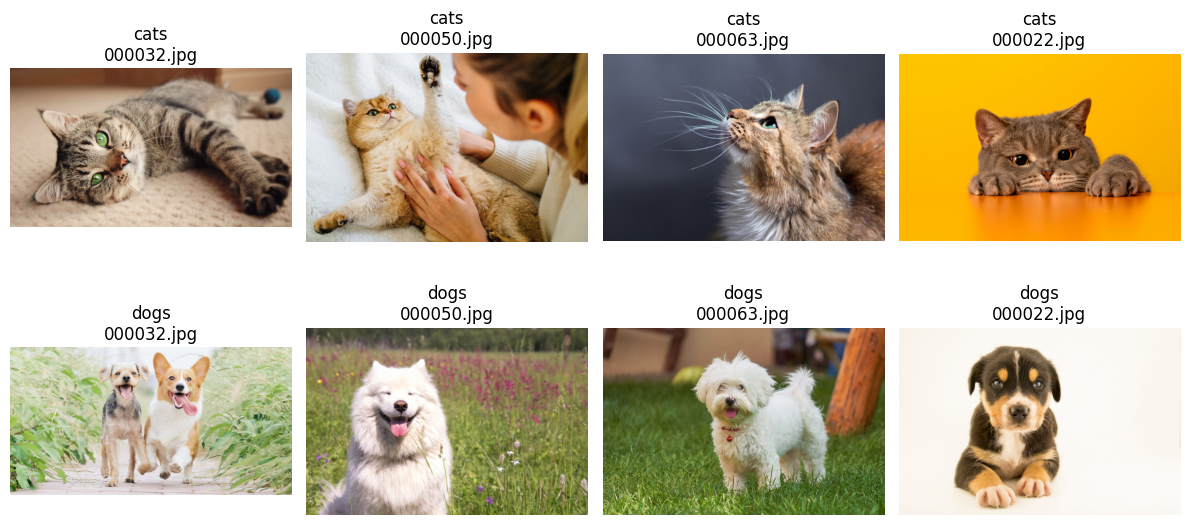

In [6]:
def visualize_sample_images(dataset_path, class_names, samples_per_class=4):
    """
    Visualize sample images from each class
    """
    dataset_path = Path(dataset_path)

    fig, axes = plt.subplots(len(class_names), samples_per_class,
                            figsize=(samples_per_class * 3, len(class_names) * 3))

    for i, class_name in enumerate(class_names):
        class_dir = dataset_path / class_name
        image_files = list(class_dir.glob('*.jpg'))[:samples_per_class]

        for j, img_path in enumerate(image_files):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if len(class_names) == 1:
                ax = axes[j]
            else:
                ax = axes[i, j]

            ax.imshow(img_rgb)
            ax.set_title(f'{class_name}\n{img_path.name}')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize samples
visualize_sample_images(path, class_names)

PREPROCESSING **PIPELINE**

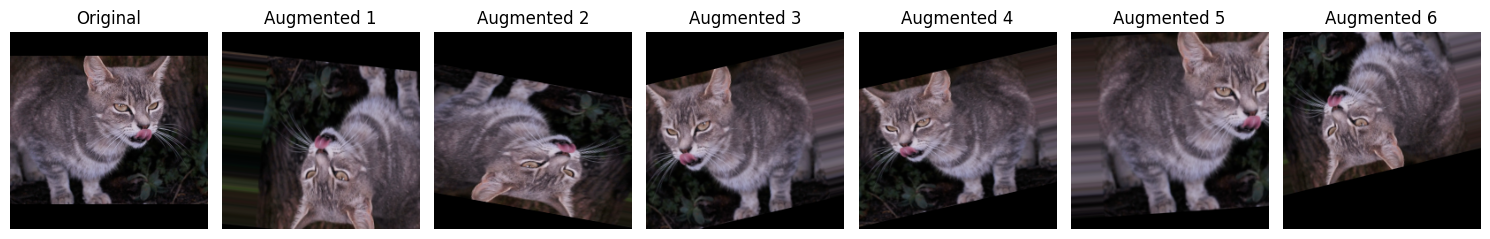

In [9]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# No augmentation for validation/test
val_datagen = ImageDataGenerator()

# Demonstrate data augmentation
def show_augmentation_examples(image, datagen, num_examples=6):
    """
    Show examples of data augmentation
    """
    # Reshape for generator
    image_batch = image.reshape((1,) + image.shape)

    fig, axes = plt.subplots(1, num_examples + 1, figsize=(15, 3))

    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original')
    axes[0].axis('off')

    # Augmented images
    i = 1
    for batch in datagen.flow(image_batch, batch_size=1):
        axes[i].imshow(batch[0])
        axes[i].set_title(f'Augmented {i}')
        axes[i].axis('off')
        i += 1
        if i > num_examples:
            break

    plt.tight_layout()
    plt.show()

# Show augmentation examples
sample_image = X_train[0]
show_augmentation_examples(sample_image, train_datagen)

## BUILDING A SIMPLE **CNN**

In [11]:
def create_simple_cnn(input_shape, num_classes):
    """
    Create a simple CNN architecture
    """
    model = models.Sequential([
        # First convolutional block
        layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),

        # Second convolutional block
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten and dense layers
        layers.Flatten(),
        layers.Dropout(0.9),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.9),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create the model
input_shape = 224, 224, 3
num_classes = 2

model = create_simple_cnn(input_shape, num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │     2,986,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,991,170 (11.41 MB)

 Trainable params: 2,991,170 (11.41 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Define callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
]

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
# Train the model
EPOCHS = 15
BATCH_SIZE = 16

history = model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4975 - loss: 0.9766 - val_accuracy: 0.5000 - val_loss: 0.6979 - learning_rate: 0.0010
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.6250 - loss: 1.3138 - val_accuracy: 0.5000 - val_loss: 0.6992 - learning_rate: 0.0010
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 788ms/step - accuracy: 0.5354 - loss: 1.7412 - val_accuracy: 0.5000 - val_loss: 0.7424 - learning_rate: 0.0010
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.8125 - loss: 0.3534 - val_accuracy: 0.5000 - val_loss: 0.7471 - learning_rate: 0.0010
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 806ms/step - accuracy: 0.4570 - loss: 1.5907 - val_accuracy: 0.5000 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.4375 - loss: 0.9996 - val_accuracy: 0.4706 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 820ms/step - accuracy: 0.4567 - loss: 0.9039 - val_accuracy: 0.411

Accuracy is very low, thus to improve it, we will use transfer learning with MobileNetV2 and
Compile the `transfer_model` using the Adam optimizer, 'sparse_categorical_crossentropy' loss function, and 'accuracy' metrics.

## BUILDING A **TRANSFER LEARNING MODEL**

In [16]:
def create_transfer_learning_model(input_shape, num_classes):
    """
    Create a transfer learning model using MobileNetV2
    """
    # Load pre-trained MobileNetV2
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze base model
    base_model.trainable = False

    # Add custom classifier
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Create transfer learning model
transfer_model = create_transfer_learning_model(input_shape, num_classes)
transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer learning model created and compiled successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Transfer learning model created and compiled successfully!


Training the transfer learning model using augmented training data and validation data, applying early stopping and learning rate reduction callbacks.


In [17]:
history_transfer = transfer_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6471 - loss: 0.7214 - val_accuracy: 0.5294 - val_loss: 0.7485 - learning_rate: 0.0010
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step - accuracy: 0.2500 - loss: 0.9657 - val_accuracy: 0.5294 - val_loss: 0.7432 - learning_rate: 0.0010
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.6424 - loss: 0.7660 - val_accuracy: 0.8235 - val_loss: 0.4623 - learning_rate: 0.0010
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step - accuracy: 0.8125 - loss: 0.4084 - val_accuracy: 0.7941 - val_loss: 0.4391 - learning_rate: 0.0010
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8233 - loss: 0.3946 - val_accuracy: 0.7941 - val_loss: 0.4355 - learning_rate: 0.0010
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 271ms/step - accuracy: 0.7500 - loss: 0.4917 - val_accuracy: 0.7941 - val_loss: 0.4077 - learning_rate: 0.0010
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7245 - loss: 0.5007 - val_accuracy: 0.9118 - va

## Evaluate and Compare Models

Evaluate both the simple CNN and the transfer learning model on the test set, visualize their training histories, and display classification reports and confusion matrices for comparison.


In [28]:
print("\n--- Model Performance Comparison (Test Set) ---")
print(f"{'Metric':<25} | {'Simple CNN':<15} | {'Transfer Learning':<20}")
print(f"{'='*25} | {'='*15} | {'='*20}")
print(f"{'Test Loss':<25} | {loss_cnn:<15.4f} | {loss_transfer:<20.4f}")
print(f"{'Test Accuracy':<25} | {accuracy_cnn:<15.4f} | {accuracy_transfer:<20.4f}")


--- Model Performance Comparison (Test Set) ---
Metric                    | Simple CNN      | Transfer Learning   
========================= | =============== | ====================
Test Loss                 | 0.6893          | 0.1268              
Test Accuracy             | 0.5588          | 0.9706              



## Plotting the training history for the two models:
showing both accuracy and loss over epochs.



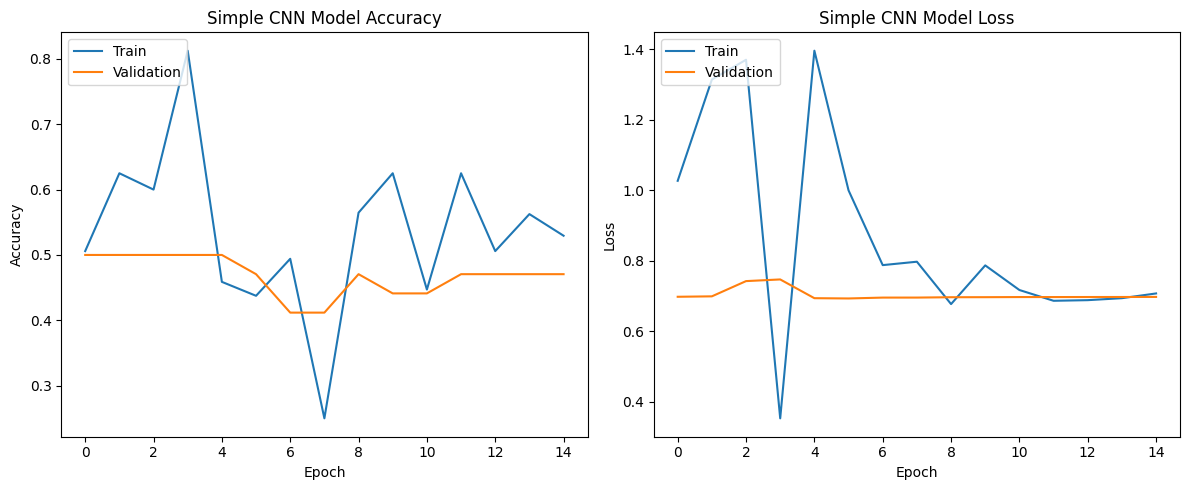

In [20]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Simple CNN Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Simple CNN Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()


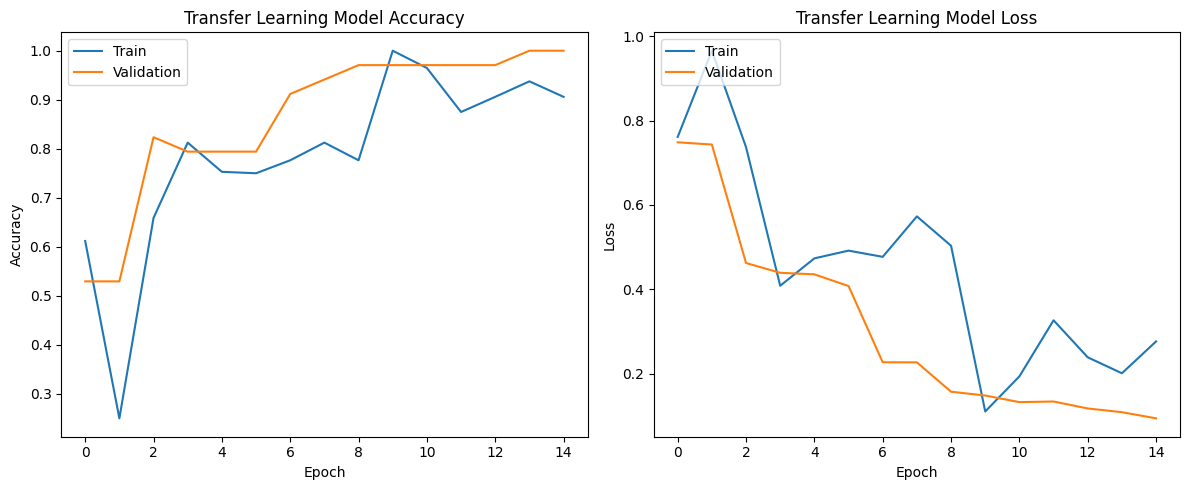

In [21]:
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values for transfer learning model
plt.subplot(1, 2, 1);
plt.plot(history_transfer.history['accuracy']);
plt.plot(history_transfer.history['val_accuracy']);
plt.title('Transfer Learning Model Accuracy');
plt.ylabel('Accuracy');
plt.xlabel('Epoch');
plt.legend(['Train', 'Validation'], loc='upper left');

# Plot training & validation loss values for transfer learning model
plt.subplot(1, 2, 2);
plt.plot(history_transfer.history['loss']);
plt.plot(history_transfer.history['val_loss']);
plt.title('Transfer Learning Model Loss');
plt.ylabel('Loss');
plt.xlabel('Epoch');
plt.legend(['Train', 'Validation'], loc='upper left');

plt.tight_layout();
plt.show();

## Model Evaluation:



**Simple CNN**:

Test Accuracy: 0.5588
Test Loss: 0.6893
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step 

Classification Report:
              precision    recall  f1-score   support

        cats       1.00      0.12      0.21        17
        dogs       0.53      1.00      0.69        17

    accuracy                           0.56        34
   macro avg       0.77      0.56      0.45        34
weighted avg       0.77      0.56      0.45        34



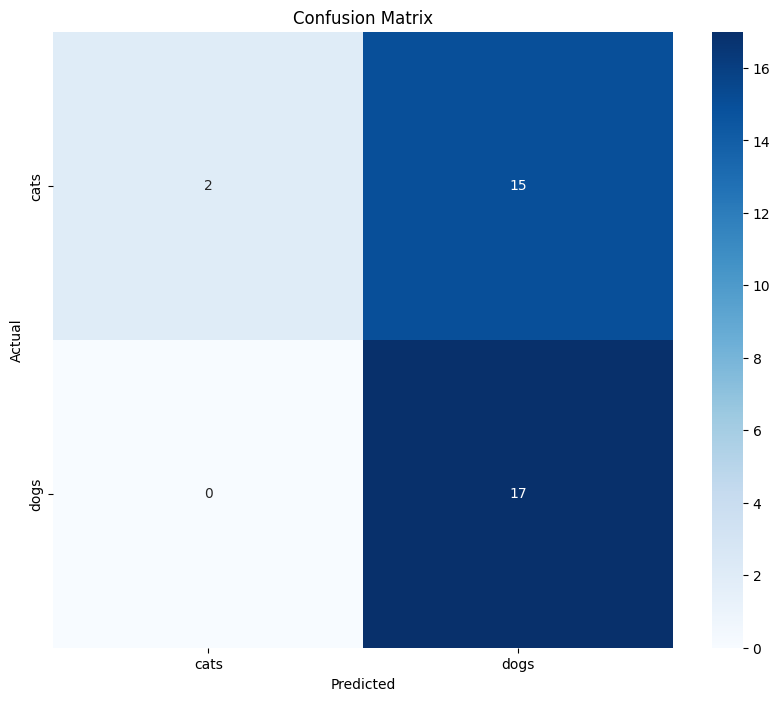

In [29]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes,
                          target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Transfer Learning Model**:


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step
Transfer Learning predictions generated.

--- Classification Report for Transfer Learning Model ---
              precision    recall  f1-score   support

        cats       1.00      0.94      0.97        17
        dogs       0.94      1.00      0.97        17

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



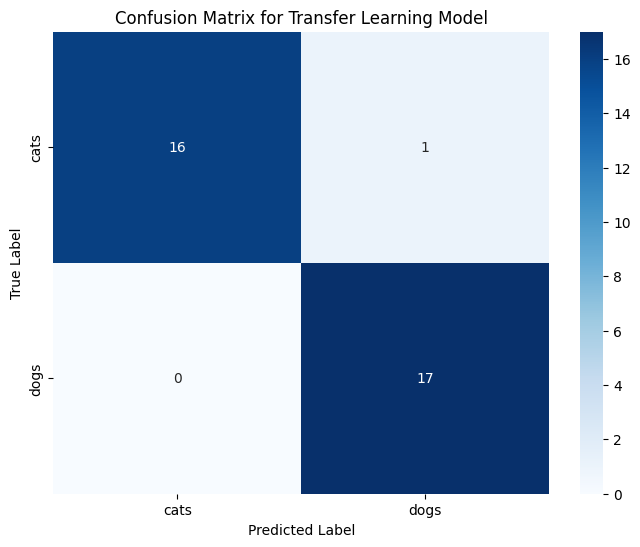

In [30]:
y_pred_transfer_probs = transfer_model.predict(X_test)
y_pred_transfer = np.argmax(y_pred_transfer_probs, axis=1)
print("Transfer Learning predictions generated.")


print("\n--- Classification Report for Transfer Learning Model ---")
print(classification_report(y_test, y_pred_transfer, target_names=class_names))


cm_transfer = confusion_matrix(y_test, y_pred_transfer)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_transfer, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Transfer Learning Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Summary:

The transfer learning model demonstrated significantly superior performance compared to the simple CNN, particularly benefiting from its ability to leverage pre-trained knowledge on a small dataset.

The key differences are:
*   **Accuracy:** The transfer learning model achieved a test accuracy of 97.06%, vastly outperforming the simple CNN's test accuracy of 55.88%.
*   **Loss:** The transfer learning model had a much lower test loss of 0.1268, compared to the simple CNN's loss of 0.6893.
*   **Class-specific Performance:** The simple CNN struggled considerably with classifying 'cats', showing a precision of 1.00 but a very low recall of 0.12. In contrast, the transfer learning model performed exceptionally well for both classes, achieving a precision of 1.00 and recall of 0.94 for 'cats', and a precision of 0.94 and recall of 1.00 for 'dogs'.
*   **Benefit for Small Datasets:** Transfer learning's ability to leverage features learned from a massive dataset (ImageNet) allowed it to generalize much better and learn robust representations from the limited local dataset, leading to significantly higher accuracy and more balanced classification across categories. The simple CNN, without such pre-trained knowledge, failed to effectively learn distinct features from the small dataset.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step

--- Simple CNN Predictions ---


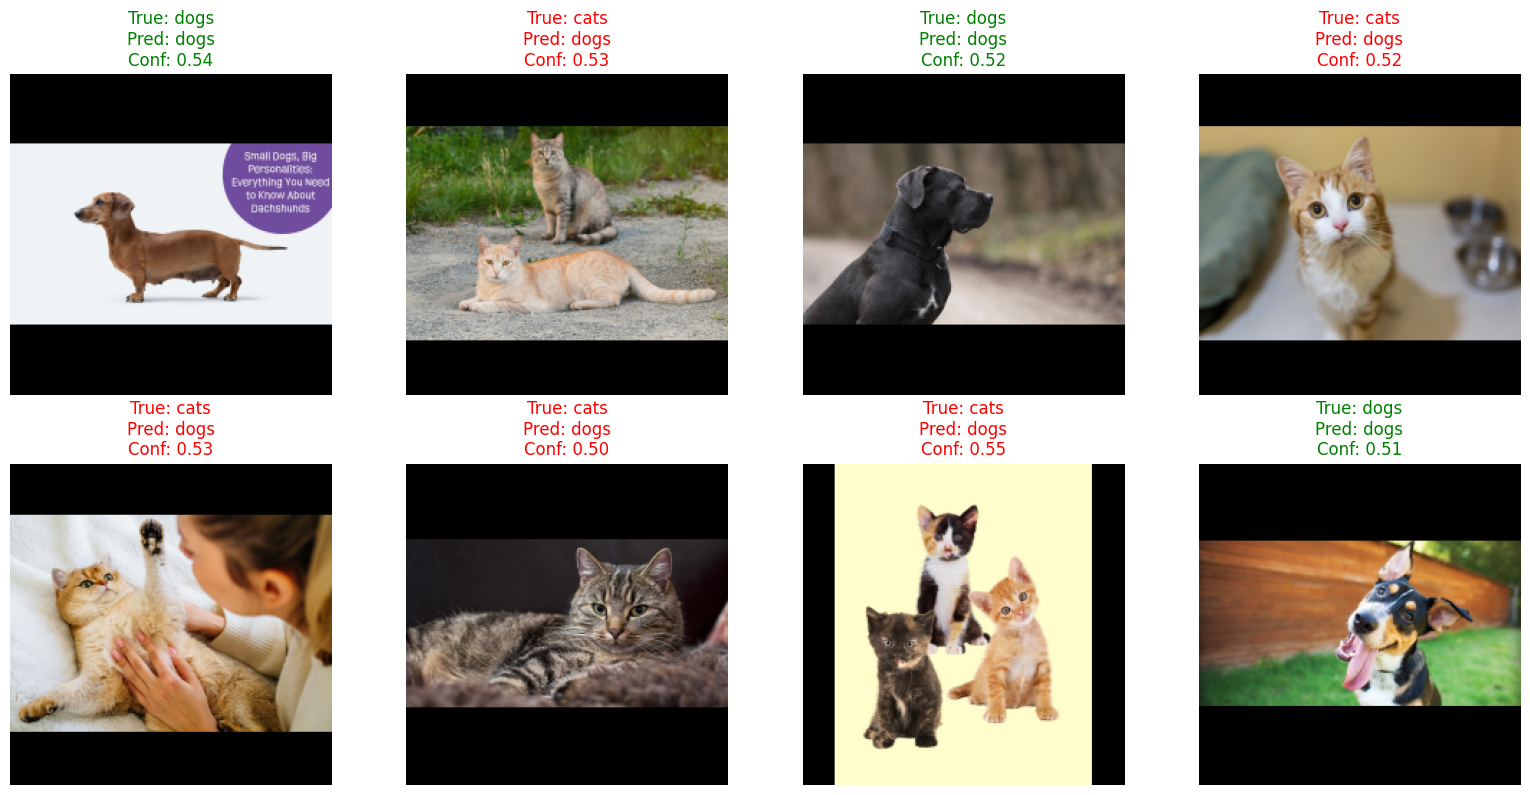

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step

--- Transfer Learning Model Predictions ---


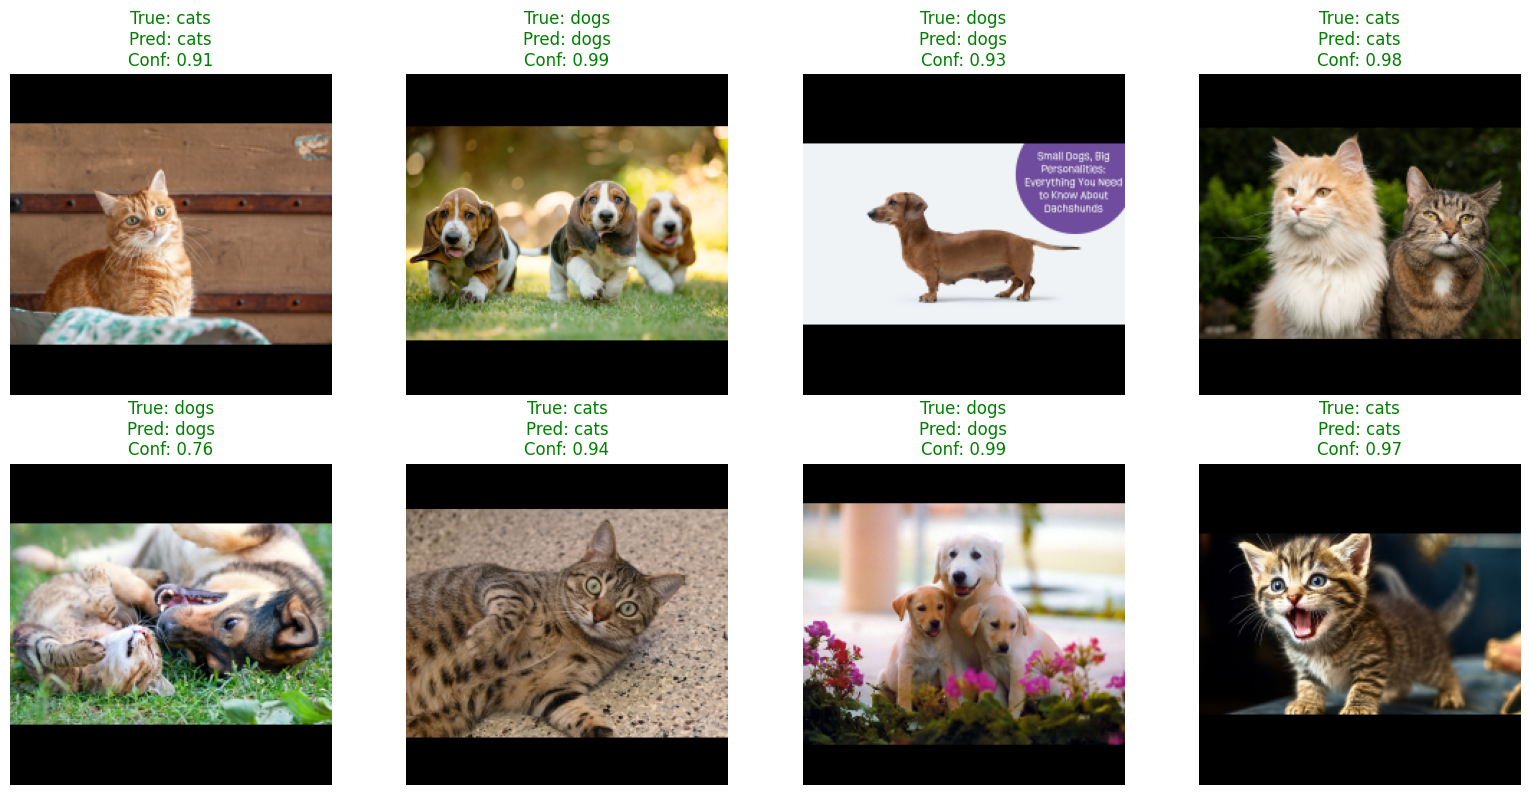

In [33]:
def show_prediction_examples(model, X_test, y_test, label_encoder, num_examples=8, model_name="Model"):
    """
    Show prediction examples with confidence scores
    """
    # Get random samples
    indices = np.random.choice(len(X_test), num_examples, replace=False)

    # Make predictions
    predictions = model.predict(X_test[indices])
    predicted_classes = np.argmax(predictions, axis=1)
    confidence_scores = np.max(predictions, axis=1)

    # Plot
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()

    print(f"\n--- {model_name} Predictions ---")

    for i, idx in enumerate(indices):
        # Display image
        axes[i].imshow(X_test[idx])

        # Get labels
        true_label = label_encoder.classes_[y_test[idx]]
        pred_label = label_encoder.classes_[predicted_classes[i]]
        confidence = confidence_scores[i]

        # Set title with color coding
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}',
                         color=color)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Show prediction examples using the Simple CNN model
show_prediction_examples(model, X_test, y_test, label_encoder, model_name="Simple CNN")

# Show prediction examples using the Transfer Learning model
show_prediction_examples(transfer_model, X_test, y_test, label_encoder, model_name="Transfer Learning Model")